From https://eloy.readthedocs.io/en/latest/photometry/

In [26]:

from astropy.io import fits
from dateutil import parser
from glob import glob

reference_file = "output/stack_image.fits"

images = glob("data/*.fits.fz")

# get observation time from FITS header (SCI extension)
def observation_time(file):

    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    return parser.parse(date_str)


# order by observation time
images = sorted(images, key=lambda file: observation_time(file))
images = [images[0], images[10], images[23]]
print(images)

['data/NxAst-pandorahatp11multibandseries_gp_2461211d71334542_20260619_1a677_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d72110899_20260619_1a611_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d94435106_20260619_1a027_15_baron.fits.fz']


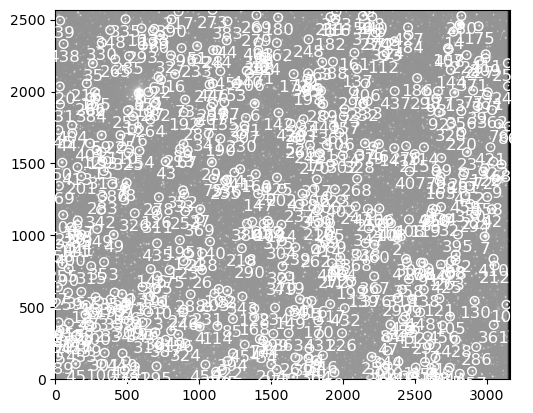

In [4]:
# calibration sequence

import numpy as np

#hot-patch numpy for compatibility with eloy
#np.in1d = np.isin

from eloy import psf, detection, utils

trim = 10
n_stars_align = 12


def calibration_sequence(file):
    # getting data
    data = fits.getdata(file)
    header = fits.getheader(file)

    # trimming
    calibrated_data = data[trim:-trim, trim:-trim]
#    calibrated_data = data

    # detection
    regions = detection.stars_detection(calibrated_data)
    # stars coords and cutouts
    region_coords = np.array([(r.centroid[1], r.centroid[0]) for r in regions])
    cutouts = utils.cutout(calibrated_data, region_coords, (50, 50))

    # epsf modeling
    cutouts_normalized = cutouts / np.nanmax(cutouts, (1, 2))[:, None, None]
    epsf = np.nanmedian(cutouts_normalized, 0)
    psf_params = psf.fit_gaussian(epsf)
    fwhm = psf.gaussian_sigma_to_fwhm * np.mean(
        [psf_params["sigma_x"], psf_params["sigma_y"]]
    )

    del (
        cutouts_normalized,
        data,
        regions,
        cutouts,
        epsf,
        header,
    )

    return calibrated_data, region_coords, fwhm


# and create a calibration sequence from the reference image
import matplotlib.pyplot as plt
from eloy import alignment, viz

ref_data, ref_coords, ref_fwhm = calibration_sequence(reference_file)
ref_reference = alignment.twirl_reference(ref_coords[0:n_stars_align])

ref_header = fits.getheader(reference_file)

plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
viz.plot_marks(*ref_coords.T, color="w", label=True, ms=30)


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

  0%|          | 0/3 [00:00<?, ?it/s]

<AffineTransform(matrix=
    [[ 9.99904508e-01, -3.12414518e-05,  3.31046231e-01],
     [-2.02164212e-05,  9.99714157e-01,  6.79891783e-01],
     [ 1.32341706e-17, -2.00577402e-17,  1.00000000e+00]]) at 0x75808023fdd0>

<AffineTransform(matrix=
    [[ 9.99894911e-01,  9.87818432e-05,  9.76582851e+00],
     [-1.04882629e-04,  9.99956932e-01, -7.92035144e-01],
     [ 1.19173445e-17, -1.91903785e-17,  1.00000000e+00]]) at 0x75808026b530>

<AffineTransform(matrix=
    [[ 9.99929051e-01,  4.89983647e-04,  1.85442079e+00],
     [-1.64674507e-04,  1.00059603e+00,  6.26422239e-02],
     [ 4.31352541e-18, -6.61363325e-18,  1.00000000e+00]]) at 0x75808017f8f0>

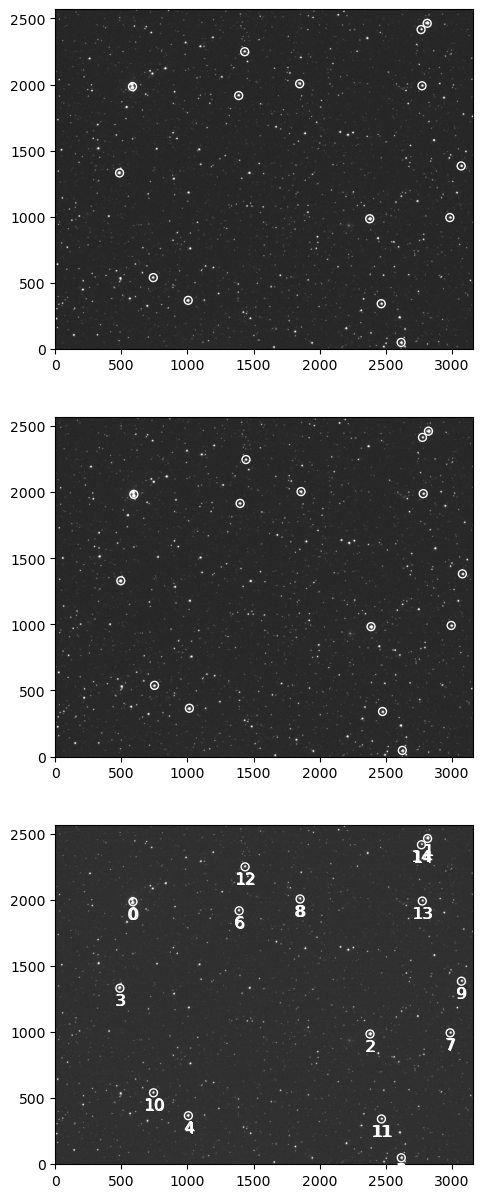

In [24]:
# now do the photometry sequence for all images

from tqdm.auto import tqdm
from skimage.transform import AffineTransform
from eloy.ballet import Ballet
from astropy.time import Time
from collections import defaultdict
from eloy import centroid, photometry

n_stars = 15
relative_apertures_radii = np.linspace(0.1, 5, 40)
cnn = Ballet()

data = defaultdict(list)

fig, axs = plt.subplots(3,1, figsize=(10, 15))
display(axs)

i=0

for file in tqdm(images):
    ax = axs[i]
    i = i+1

    calibrated_data, coords, fwhm = calibration_sequence(file)

    # alignment
    R = alignment.rotation_matrix(coords[0:n_stars_align], ref_coords, ref_reference)
    transform = AffineTransform(R)#.inverse
    display(transform)
    aligned_coords = transform(ref_coords)[0:n_stars]
    dx, dy = np.median(ref_coords[0:n_stars] - aligned_coords, 0)

    # centroiding
    centroid_coords = centroid.ballet_centroid(calibrated_data, aligned_coords, cnn)
    # aperture photometry
    apertures_radii = relative_apertures_radii * fwhm
    flux = photometry.aperture_photometry(
        calibrated_data, centroid_coords, apertures_radii
    )
    # annulus background correction
    annulus_radii = np.max(apertures_radii), 8 * fwhm
    aperture_area = np.pi * apertures_radii**2
    bkg = photometry.annulus_sigma_clip_median(
        calibrated_data, centroid_coords, *annulus_radii
    )
    bkg = bkg[:, None] * aperture_area[None, :]

    #render the image and the detected stars
    ax.imshow(viz.z_scale(calibrated_data), cmap="Greys_r", origin="lower")
    viz.plot_marks(*centroid_coords.T, color="w", label=True, ms=30, ax=ax)

    # getting data
    header = fits.open(file)[0].header
    data["bkg"].append(bkg)
    data["fluxes"].append(flux)
    data["fwhm"].append(fwhm)
    
    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    jd = Time(parser.parse(date_str)).jd

    #jd = Time(parser.parse(header["DATE-OBS"])).jd
    data["time"].append(jd)
    data["dx"].append(dx)
    data["dy"].append(dy)


for k, v in data.items():
    data[k] = np.array(v)


In [6]:
data["fluxes"].shape

(3, 100, 40)

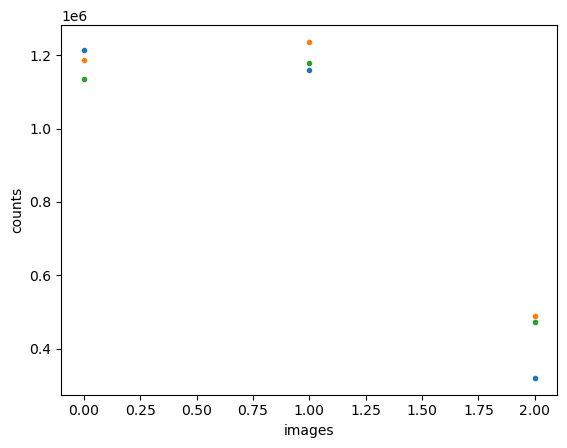

In [25]:
import matplotlib.pyplot as plt

#plot some random photometry data
for i in range(3):
    plt.plot(data["fluxes"][:, i, 20], ".")
plt.xlabel("images")
_ = plt.ylabel("counts")


Target index is 2
[2378.62021858  982.94808743]
<SkyCoord (ICRS): (ra, dec) in deg
    (297.71352425, 48.08124187)>
<SkyCoord (ICRS): (ra, dec) in deg
    (297.70936374, 48.0808615)>


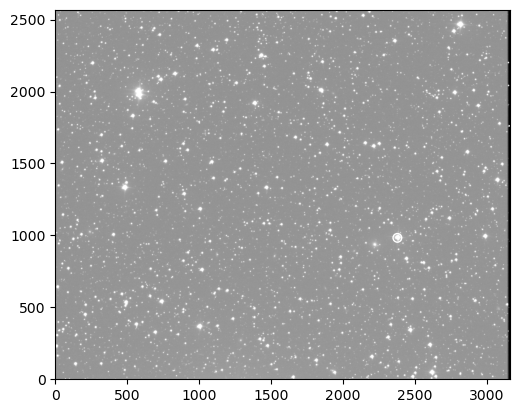

In [27]:
# need to identify the target!
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


#transform ref_coords to skycoords
wcs = WCS(ref_header)
centroid_radec = wcs.pixel_to_world(*ref_coords.T)

mast = Mast()
target_radec = mast.resolve_object("HAT-P-11")
target_index = int(target_radec.match_to_catalog_sky(centroid_radec)[0])

print(f"Target index is {target_index}")
print(f"{ref_coords[target_index]}")
print(f"{centroid_radec[target_index]}")
print(f"{target_radec}")

plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
viz.plot_marks(ref_coords[target_index][0],ref_coords[target_index][1], color="w", ms=30)

target = ref_coords[target_index]


(44, 100, 40)

In [28]:
# "In order to perform differential photometry eloy implements the Broeg 2005 algorithm.""

from eloy import flux

# we remove the background from the annulus aperture
fluxes = (data["fluxes"] - data["bkg"]).T

display(fluxes.shape)
# and perform different photometry
diffs, weights = flux.auto_diff(fluxes, target_index)

# finally we find the 'optimal' aperture for our target
best_aperture = flux.optimal_flux(diffs[:, target_index])
diff = diffs[best_aperture, target_index]

display(diff)

(40, 15, 3)

/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/eloy/flux.py:97: RuntimeWarning: invalid value encountered in divide
  artificial_light_curve = (sub @ weighted_fluxes) / np.expand_dims(
/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/eloy/utils.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(


array([0.98787659, 1.00042272, 1.03215547])

In [29]:
display(fluxes)
display(diffs)
display(target_index)

array([[[2.01548032e+02, 1.93687005e+02, 5.15113569e+01],
        [2.61658236e+04, 3.00148906e+04, 1.00500264e+04],
        [2.06598572e+04, 2.78056901e+04, 1.01433445e+04],
        ...,
        [4.00563063e+03, 4.32881959e+03, 1.53812055e+03],
        [4.32720046e+03, 4.54586664e+03, 1.46341608e+03],
        [2.91734567e+03, 3.72292382e+03, 1.11635750e+03]],

       [[1.16945435e+03, 9.55688452e+02, 2.69700760e+02],
        [1.30829224e+05, 1.32200929e+05, 4.92291559e+04],
        [1.02977459e+05, 1.22959576e+05, 4.23768323e+04],
        ...,
        [2.02368099e+04, 2.02585017e+04, 7.54257795e+03],
        [2.05648212e+04, 2.11463813e+04, 6.52896510e+03],
        [1.40475225e+04, 1.61088482e+04, 5.23791248e+03]],

       [[3.04753683e+03, 2.43791954e+03, 7.13291044e+02],
        [2.72174303e+05, 2.88723829e+05, 1.05276400e+05],
        [2.25847116e+05, 2.64782640e+05, 9.29394575e+04],
        ...,
        [4.42668121e+04, 4.44348597e+04, 1.65036201e+04],
        [4.49891667e+04, 4.59

array([[[1.14994243, 0.95064731, 0.76046978],
        [1.02236932, 0.98047272, 1.00252148],
        [0.89850893, 1.0402798 , 1.1414521 ],
        ...,
        [1.03418739, 0.96143345, 1.02754334],
        [1.06706975, 0.96432602, 0.93375953],
        [0.9586798 , 1.0524252 , 0.94922772]],

       [[1.16551201, 0.94258403, 0.71432858],
        [       nan,        nan,        nan],
        [0.91602997, 1.08243076, 1.00179388],
        ...,
        [1.00546918, 0.9961031 , 0.99593018],
        [1.01748206, 1.03539995, 0.85847676],
        [0.94727755, 1.07500938, 0.9386812 ]],

       [[1.20333328, 0.90744607, 0.72814829],
        [       nan,        nan,        nan],
        [0.94724666, 1.04689357, 1.00777774],
        ...,
        [1.02986801, 0.97452195, 0.99265568],
        [1.04029421, 1.00149699, 0.89172061],
        [0.96931056, 1.04936476, 0.94395797]],

       ...,

       [[1.00536004, 1.02584125, 0.91288622],
        [0.99397702, 0.99332387, 1.0349259 ],
        [0.99381439, 0

2

In [30]:
display(data["time"])
utils.index_binning(data["time"], 0.005)

array([2461211.71099376, 2461211.71875708, 2461211.94205001])

[array([0]), array([1]), array([2])]

In [40]:
idxs = utils.index_binning(data["time"], 0.005)
binned_time = [data["time"][i].mean() for i in idxs]
binned_diff = [diff[i].mean() for i in idxs]
binned_error = [diff[i].std() / np.sqrt(len(i)) for i in idxs]


plt.plot(data["time"], diffs[best_aperture, target_index, :], ".", c="0.8")
plt.errorbar(binned_time, binned_diff, yerr=binned_error, fmt=".", c="k")
plt.ylim(0.96, 1.04)
plt.xlabel("time (JD)")
_ = plt.ylabel("Diff. flux")


IndexError: index 40 is out of bounds for axis 0 with size 40

In [ ]:
print(fluxes)

[[[ 1.92600140e+02  1.70737855e+02  1.96818639e+02 ...  1.83747077e+00
   -2.33023982e+00  1.05432697e-02]
  [ 2.27480847e+04  2.16822582e+04  2.38235377e+04 ...  4.31181337e+00
   -1.12330706e+00  6.81116745e-01]
  [ 1.81029017e+04  2.47880174e+04  2.32874819e+04 ... -8.84485975e-01
   -1.66368470e+00 -1.02428002e-01]
  ...
  [ 1.60954861e+02  1.79369240e+02  1.61893739e+02 ...  2.22691324e+00
   -1.82822666e+00  1.39026118e+00]
  [ 1.77464506e+02  1.44540362e+02  1.68283504e+02 ...  7.30319520e-02
    1.20182912e+00 -5.87969768e-02]
  [ 1.88383819e+02  1.37717669e+02  1.49449708e+02 ... -7.89365617e-01
   -7.70971023e-01 -1.22844515e+00]]

 [[ 1.20556490e+03  8.38910487e+02  9.76654640e+02 ...  6.71604687e+00
   -1.58652615e+01 -1.95139925e+00]
  [ 1.11261938e+05  1.10203186e+05  1.16908044e+05 ...  9.42077903e+00
   -5.45769171e+00  2.40496863e+00]
  [ 8.59804372e+04  1.15297464e+05  1.05478792e+05 ...  1.62650313e+00
   -6.14403512e+00 -1.31687447e+00]
  ...
  [ 7.98961470e+02  8.3